**Importacion de librerias y dataset**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use("ggplot")
sns.set_theme()

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

df = pd.read_excel("data/infracciones_de_transito_por_tipo_y_zona.xlsx")

df.head()

,Nro Comparendo,Fecha Comparendo,Secretaría,Tipo Documento,Cédula Infractor,Nombre,Infracciones Comparendo,Valor,Dirección Infracción
0,'99999999000006122775,2025-01-01,Sampues - Dptal Sucre,Cédula,11028*****,OBER,C15,377456,TR TOLUVIEJO SINCELEJO - KM 15+300
1,'99999999000006122726,2025-01-01,Sampues - Dptal Sucre,Cédula,11028*****,OBER,D01,754912,TR TOLUVIEJO SINCELEJO - KM 15+300
2,'99999999000006122776,2025-01-01,Sampues - Dptal Sucre,Cédula,920*****,JOSE,D01,1207860,TR TOLUVIEJO SINCELEJO - KM 15+300
3,'99999999000006122782,2025-01-01,Sampues - Dptal Sucre,Cédula,920*****,JOSE,C24,603930,TR TOLUVIEJO SINCELEJO - KM 15+300
4,'99999999000006124383,2025-01-01,Sampues - Dptal Sucre,Cédula,87*****,ARIEL CAYETANO,D13,1207860,VI SANONOFRECRUZDELVISO - KM 21+300


**Exploraicon inicial**

In [9]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 33475 entries, 0 to 33474
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Nro Comparendo           33475 non-null  str           
 1   Fecha Comparendo         33475 non-null  datetime64[us]
 2   Secretaría               33475 non-null  str           
 3   Tipo Documento           33475 non-null  str           
 4   Cédula Infractor         33475 non-null  str           
 5   Nombre                   33475 non-null  str           
 6   Infracciones Comparendo  33475 non-null  str           
 7   Valor                    33475 non-null  int64         
 8   Dirección Infracción     33475 non-null  str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 2.3 MB


,Fecha Comparendo,Valor
count,33475,3.347500e+04
mean,2025-07-09 13:59:18.488424,7.486154e+05
min,2025-01-01 00:00:00,0.000000e+00
25%,2025-05-15 00:00:00,6.039300e+05
50%,2025-07-11 00:00:00,6.039300e+05
75%,2025-09-10 00:00:00,1.207860e+06
max,2025-11-12 00:00:00,2.898864e+07
std,NaN,3.350793e+05


**Limpieza**

In [ ]:
# borrar ducplicados
df = df.drop_duplicates()

#verificar si hay valores nulos
print(df.isnull().sum())

#revisar valores unicos en columnas categóricas
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())

Nro Comparendo             0
Fecha Comparendo           0
Secretaría                 0
Tipo Documento             0
Cédula Infractor           0
Nombre                     0
Infracciones Comparendo    0
Valor                      0
Dirección Infracción       0
dtype: int64

 Nro Comparendo
<StringArray>
[''99999999000006122775', ''99999999000006122726', ''99999999000006122776',
 ''99999999000006122782', ''99999999000006124383', ''99999999000006124382',
 ''99999999000006124432', ''99999999000006122778', ''99999999000006122816',
 ''99999999000006124471',
 ...
 ''99999999000006464698', ''99999999000006464718', ''99999999000006464614',
 ''99999999000006464615', ''99999999000006464715', ''99999999000006464722',
 ''99999999000006464695', ''99999999000006464637', ''99999999000006464696',
 ''99999999000006464719']
Length: 33473, dtype: str

 Secretaría
<StringArray>
['Sampues - Dptal Sucre']
Length: 1, dtype: str

 Tipo Documento
<StringArray>
[                     'Cédula',           'Cédula 

/tmp/ipykernel_14137/1330875811.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


**Guardar dataset limpio**

In [22]:
df.to_csv("infracciones_limpio.csv", index=False)

**EDA univariado**

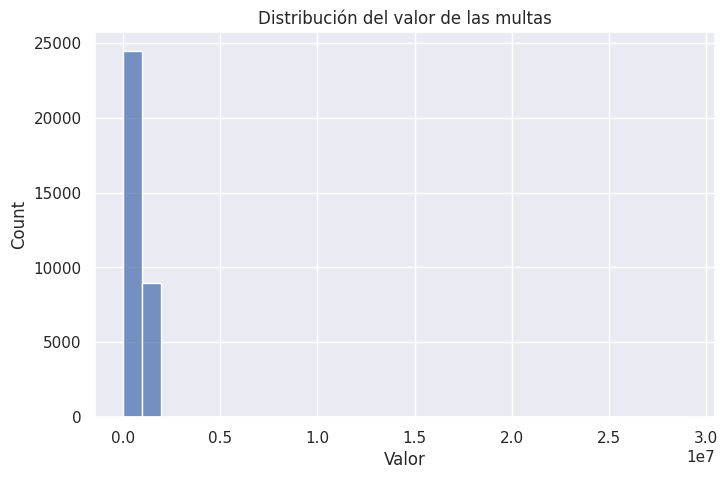

In [ ]:
#Distribución del valor de las multas
plt.figure(figsize=(8,5))
sns.histplot(df["Valor"], bins=30)

plt.title("Distribución del valor de las multas")
plt.show()

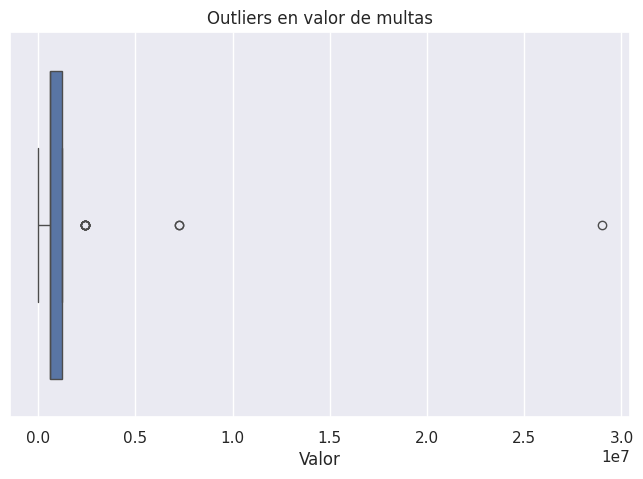

In [ ]:
#Detectar outliers en el valor de las multas
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Valor"])

plt.title("Outliers en valor de multas")
plt.show()

In [ ]:
#infracciones más comunes
df["Infracciones Comparendo"].value_counts().head(10)

Infracciones Comparendo
C29    9569
C35    8405
D02    8015
C24    4052
D01    1073
C31     484
C15     376
D13     302
H02     279
D12     260
Name: count, dtype: int64

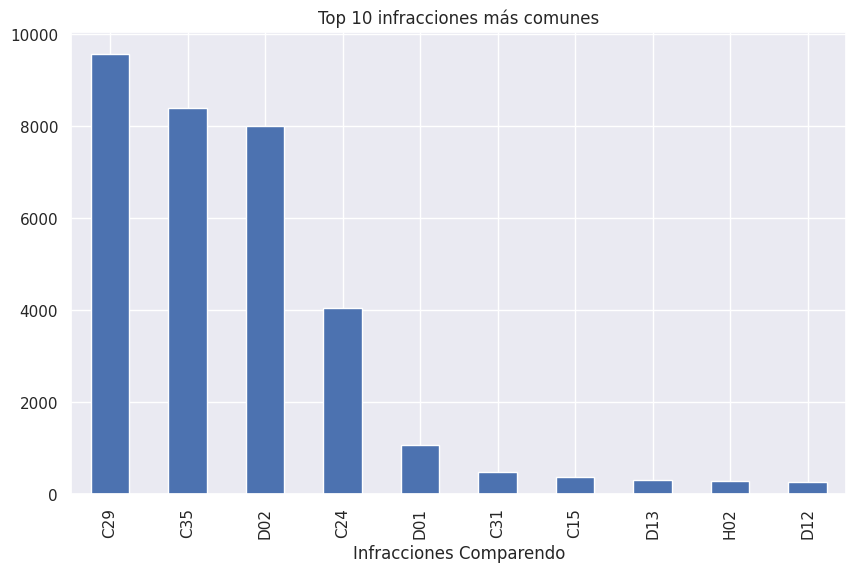

In [ ]:
#grafico de barras de las infracciones más comunes
plt.figure(figsize=(10,6))

df["Infracciones Comparendo"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 infracciones más comunes")
plt.show()

**EDA bivariado**

aqui realizaremos un analisis mes a mes de los datos

In [30]:
df["Mes"] = df["Fecha Comparendo"].dt.month_name()
# Infracciones por mes
df.groupby("Mes").size()

Mes
April        4002
August       3709
February      716
January       894
July         5136
June         4726
March        1053
May          3762
November      928
October      5141
September    3408
dtype: int64

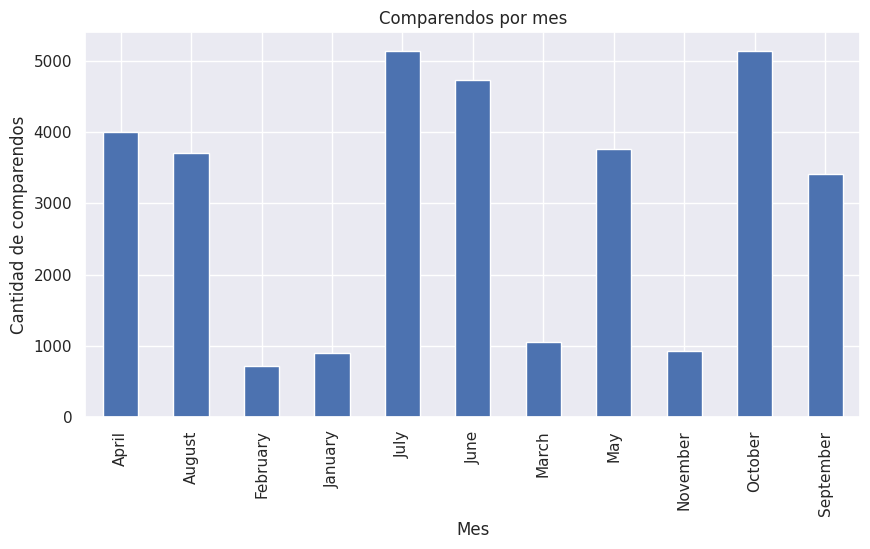

In [ ]:
# Gráfico de barras de infracciones por mes
df.groupby("Mes").size().plot(kind="bar", figsize=(10,5))

plt.title("Comparendos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de comparendos")

plt.show()

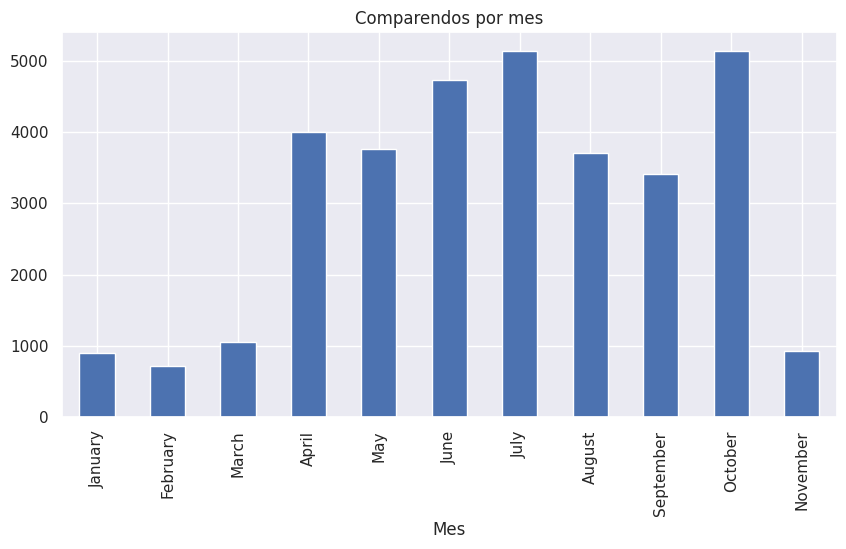

In [34]:
# Para ordenar los meses correctamente en el gráfico, podemos convertir la columna "Mes" a un tipo categórico con un orden específico

orden_meses = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

df["Mes"] = pd.Categorical(df["Mes"], categories=orden_meses, ordered=True)

df.groupby("Mes").size().plot(kind="bar", figsize=(10,5))
plt.title("Comparendos por mes")
plt.show()

In [ ]:
# Infracciones por mes y tipo de infracción

tabla = pd.crosstab(df["Mes"], df["Infracciones Comparendo"])

tabla

Infracciones Comparendo,B01,B02,B03,B05,B07,B08,B20,B22,C04,C06,C11,C13,C14,C15,C20,C22,C24,C27,C28,C29,C30,C31,C35,C37,C38,D01,D02,D03,D06,D07,D08,D12,D13,D15,F,H02,H03,H13
Mes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
January,1,17,1,1,0,1,1,0,0,0,1,0,19,69,0,0,300,0,0,1,0,67,83,1,0,89,152,8,6,0,0,18,38,0,1,18,0,1
February,1,17,1,0,1,0,0,0,0,1,0,0,0,36,0,2,296,0,0,0,0,48,72,1,0,69,116,3,3,2,0,13,23,0,0,11,0,0
March,2,16,7,0,1,0,0,0,0,0,1,0,21,32,0,2,342,0,1,0,0,82,140,1,0,49,295,6,4,2,0,16,27,0,0,6,0,0
April,4,15,0,0,1,0,0,0,0,0,0,0,29,18,0,0,192,0,0,2246,0,62,712,2,0,36,651,0,1,0,1,8,22,0,1,1,0,0
May,4,8,1,0,3,0,0,0,0,0,1,0,7,20,0,12,270,0,0,953,0,7,1240,0,1,50,1134,0,3,0,1,9,24,0,1,13,0,0
June,1,17,1,1,5,0,0,0,0,1,0,1,24,35,0,16,415,0,0,1282,0,35,1432,4,0,100,1289,1,5,0,0,18,28,0,0,15,0,0
July,4,36,6,0,8,0,0,0,1,1,1,0,0,51,1,37,599,1,1,1030,0,78,1551,0,0,180,1404,1,12,1,1,55,41,0,0,35,0,0
August,4,19,1,0,7,0,0,0,0,0,0,0,5,61,0,17,586,0,0,998,0,37,910,1,0,123,814,1,4,0,2,38,48,0,0,33,0,0
September,3,25,3,0,0,1,0,0,0,0,0,0,0,40,1,11,598,1,0,753,0,21,791,4,0,182,826,2,2,1,1,31,22,0,0,89,0,0


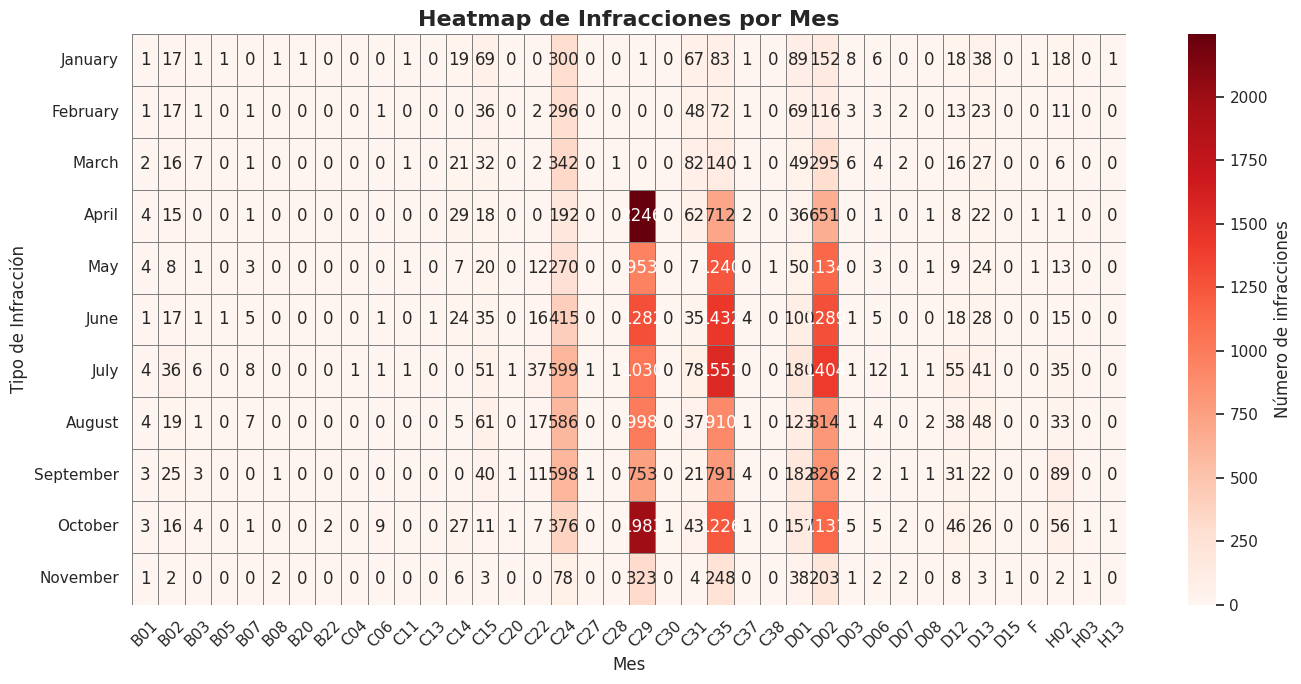

In [37]:
plt.figure(figsize=(14,7))

sns.heatmap(
    tabla,
    cmap="Reds",
    annot=True,           # muestra los valores en cada celda
    fmt="d",              # formato de número entero
    linewidths=0.5,       # líneas entre celdas
    linecolor="gray",
    cbar_kws={'label': 'Número de infracciones'}
)

plt.title("Heatmap de Infracciones por Mes", fontsize=16, fontweight="bold")
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Tipo de Infracción", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Comparación valor por infracción**

/tmp/ipykernel_14137/1602701069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


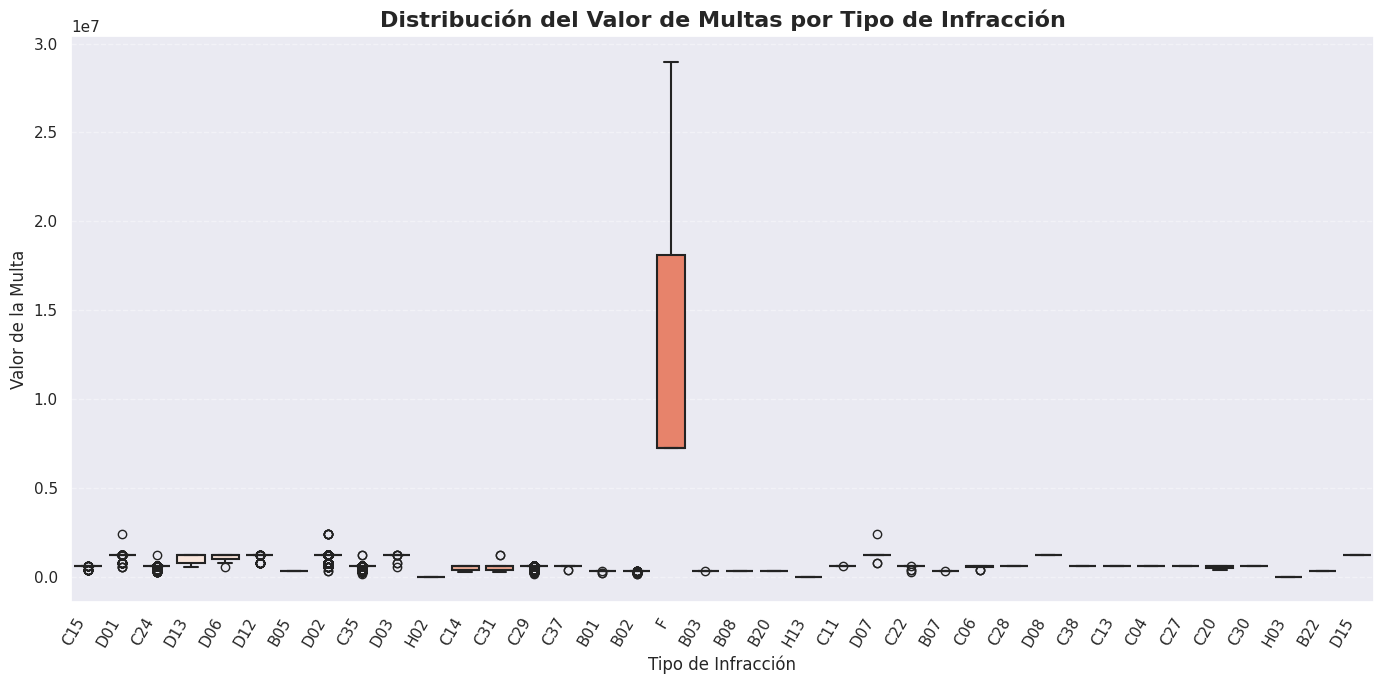

In [39]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x="Infracciones Comparendo",
    y="Valor",
    palette="Reds",
    linewidth=1.5
)

plt.xticks(rotation=60, ha="right")

plt.title("Distribución del Valor de Multas por Tipo de Infracción", 
          fontsize=16, fontweight="bold")

plt.xlabel("Tipo de Infracción", fontsize=12)
plt.ylabel("Valor de la Multa", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Datos mas detallados**

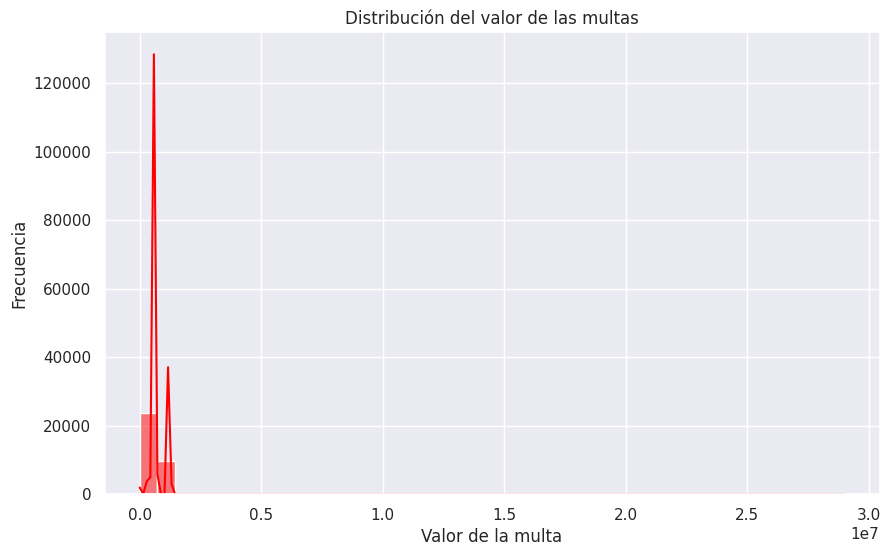

In [54]:
plt.figure(figsize=(10,6))

sns.histplot(df["Valor"], bins=40, kde=True, color="red")

plt.title("Distribución del valor de las multas")
plt.xlabel("Valor de la multa")
plt.ylabel("Frecuencia")

plt.show()

In [53]:
resumen = {
    "Media": valor.mean(),
    "Mediana": valor.median(),
    "Moda": valor.mode()[0],
    "Desviación estándar": valor.std(),
    "Valor mínimo": valor.min(),
    "Valor máximo": valor.max(),
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Límite inferior": limite_inferior,
    "Límite superior": limite_superior
}

import pandas as pd
pd.DataFrame(resumen, index=["Valor"])

,Media,Mediana,Moda,Desviación estándar,Valor mínimo,Valor máximo,Q1,Q3,IQR,Límite inferior,Límite superior
Valor,748615.405258,603930.0,603930,335079.270916,0,28988640,603930.0,1207860.0,603930.0,-301965.0,2113755.0


In [50]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("\nLÍMITES PARA OUTLIERS")
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)


LÍMITES PARA OUTLIERS
Límite inferior: -301965.0
Límite superior: 2113755.0


In [51]:
outliers = df[(valor < limite_inferior) | (valor > limite_superior)]

print("\nCantidad de outliers:", len(outliers))

outliers.head()


Cantidad de outliers: 11


,Nro Comparendo,Fecha Comparendo,Secretaría,Tipo Documento,Cédula Infractor,Nombre,Infracciones Comparendo,Valor,Dirección Infracción,Mes
273,'99999999000006123252,2025-01-11,Sampues - Dptal Sucre,Cédula,157*****,MARIO ALBERTO,F,28988640,TR PLANETARICASINCELEJO - KM 110+700,January
1197,'99999999000006122238,2025-02-12,Sampues - Dptal Sucre,Cédula,921*****,ALEXANDER ENRIQUE,D02,2415720,VI SINCELEJO-CALAMAR - KM 5+500,February
1436,'99999999000006123625,2025-02-21,Sampues - Dptal Sucre,Cédula,925*****,ORLANDO ENRIQUE,D02,2415720,TR PLANETARICASINCELEJO - KM 108,February
1531,'99999999000006019141,2025-02-26,Sampues - Dptal Sucre,Cédula,11006*****,NICOL DOUGLAS,D02,2415720,TR PLANETARICASINCELEJO - KM 104,February
1573,'99999999000006019401,2025-02-27,Sampues - Dptal Sucre,Cédula,11028*****,ARMANDO CESAR,D07,2415720,TR PLANETARICASINCELEJO - KM 109,February


In [ ]:
print("\nOUTLIERS MÁS GRANDES")

outliers.sort_values("Valor", ascending=False).head(10)


OUTLIERS MÁS GRANDES


,Nro Comparendo,Fecha Comparendo,Secretaría,Tipo Documento,Cédula Infractor,Nombre,Infracciones Comparendo,Valor,Dirección Infracción,Mes
273,'99999999000006123252,2025-01-11,Sampues - Dptal Sucre,Cédula,157*****,MARIO ALBERTO,F,28988640,TR PLANETARICASINCELEJO - KM 110+700,January
4221,'99999999000006235247,2025-04-18,Sampues - Dptal Sucre,Cédula,706*****,SERGIO ALONSO,F,7247160,VI SINCELEJO CALAMAR - KM 05+500,April
9395,'99999999000006124052,2025-05-24,Sampues - Dptal Sucre,Cédula,101*****,JOSE RAUL,F,7247160,TR SINCELEJO CALAMAR - KM 5+500,May
1436,'99999999000006123625,2025-02-21,Sampues - Dptal Sucre,Cédula,925*****,ORLANDO ENRIQUE,D02,2415720,TR PLANETARICASINCELEJO - KM 108,February
1197,'99999999000006122238,2025-02-12,Sampues - Dptal Sucre,Cédula,921*****,ALEXANDER ENRIQUE,D02,2415720,VI SINCELEJO-CALAMAR - KM 5+500,February
1531,'99999999000006019141,2025-02-26,Sampues - Dptal Sucre,Cédula,11006*****,NICOL DOUGLAS,D02,2415720,TR PLANETARICASINCELEJO - KM 104,February
1573,'99999999000006019401,2025-02-27,Sampues - Dptal Sucre,Cédula,11028*****,ARMANDO CESAR,D07,2415720,TR PLANETARICASINCELEJO - KM 109,February
3938,'99999999000006235237,2025-04-17,Sampues - Dptal Sucre,Cédula,10056*****,EVER JOSE,D02,2415720,VI LORICA - SAN ONOFRE - KM 61,April
2609,'99999999000006236415,2025-03-29,Sampues - Dptal Sucre,Cédula,10033*****,LUIS MIGUEL,D01,2415720,VI LORICA SAN ONOFRE - KM 39+900,March
15740,'99999999000006236847,2025-07-04,Sampues - Dptal Sucre,Cédula,110321****,FREY DAVID,D02,2415720,VI SINCELEJO-CALAMAR - KM 26,July


In [45]:
df["Valor"].describe()

count    3.347500e+04
mean     7.486154e+05
std      3.350793e+05
min      0.000000e+00
25%      6.039300e+05
50%      6.039300e+05
75%      1.207860e+06
max      2.898864e+07
Name: Valor, dtype: float64

**informacion fianl**


,Media,Mediana,Moda,Desviación estándar,Valor mínimo,Valor máximo,Q1,Q3,IQR,Límite inferior,Límite superior
Valor,748615.405258,603930.0,603930,335079.270916,0,28988640,603930.0,1207860.0,603930.0,-301965.0,2113755.0
